# Week 5 - Spark Fundamentals and Data Processing
## Objective

The objective of this assignment is to understand the basic concepts of Apache Spark and perform data cleaning, filtering, transformation, and aggregation using PySpark DataFrames. This assignment also helps in understanding how Spark processes data efficiently and how multiple DataFrame operations can be combined to solve real-world data processing tasks.

# Step 1 - Understand Basics

In this step, I learned the basic concepts of Apache Spark and compared it with the traditional MapReduce framework. I also understood why Spark is widely used for modern big data processing.


## Q1. What are the key limitations of traditional MapReduce that make Spark a preferred choice for modern big data processing?

Traditional MapReduce processes data in multiple stages and stores intermediate results on disk after every stage. This increases execution time and makes repeated processing slower. It also requires more code for complex data processing tasks and is not suitable for real-time or iterative applications.

Apache Spark overcomes these limitations by processing data in memory whenever possible. It provides faster execution, supports iterative processing, and offers built-in libraries for SQL, machine learning, graph processing, and streaming. These features make Spark a preferred choice for modern big data processing.

### Observation

From this question, I understood that the main limitation of MapReduce is its dependence on disk-based processing, which makes it slower. Spark improves performance by using in-memory computing and provides better support for modern data processing tasks.

## Q2. Explain how Spark uses In-Memory Computing to speed up iterative machine learning algorithms compared to disk-based systems.

Spark uses in-memory computing to store frequently used data in RAM instead of reading it from disk every time an operation is performed. This reduces disk input/output operations and improves processing speed.

In iterative machine learning algorithms, the same dataset is processed multiple times. Since Spark keeps the data in memory, it can reuse the data without loading it from disk repeatedly. As a result, Spark executes machine learning tasks much faster than traditional disk-based systems such as MapReduce.

### Observation

From this question, I learned that Spark improves performance by keeping data in memory during processing. This reduces disk access and makes iterative tasks like machine learning much faster than traditional MapReduce.

# Step 2 - Start Spark

In this step, I imported the required PySpark libraries and created a Spark Session. The Spark Session is the entry point for working with Spark DataFrames and performing data processing tasks.

In [1]:
import pyspark
print(pyspark.__version__)

4.2.0


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [3]:


spark = SparkSession.builder \
    .appName("Week5") \
    .getOrCreate()

c:\Users\SANGITA\OneDrive\Desktop\Celebal-Summer-Internship-2026\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [4]:
spark.version

'4.2.0'

# Step 3 - Load Data

In this step, I loaded the CSV dataset into a Spark DataFrame. After loading the dataset, I viewed the first few rows and verified the column names and data types.

## Dataset Preparation

For this assignment, I created a sample sales dataset containing customer transactions. The dataset includes duplicate records, null values, empty fields, different regions, and multiple product categories. These records will be used to demonstrate different Spark DataFrame operations in the following tasks.

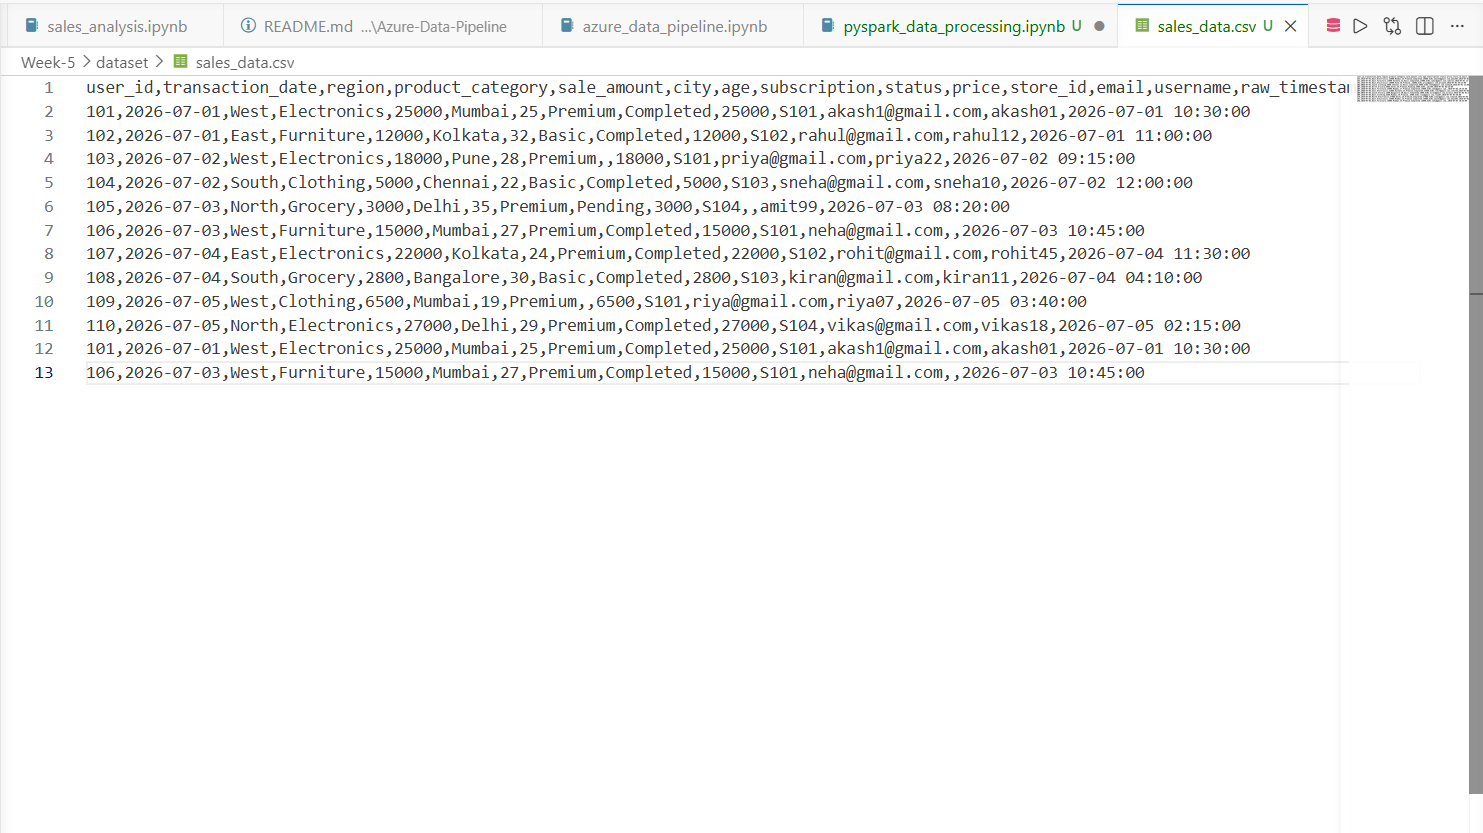

In [5]:
df = spark.read.csv(
    "../dataset/sales_data.csv",
    header=True,
    inferSchema=True
)

df.show()
df.printSchema()



+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|     city|age|subscription|   status|price|store_id|           email|username|      raw_timestamp|
+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    101|      2026-07-01|  West|     Electronics|      25000|   Mumbai| 25|     Premium|Completed|25000|    S101|akash1@gmail.com| akash01|2026-07-01 10:30:00|
|    102|      2026-07-01|  East|       Furniture|      12000|  Kolkata| 32|       Basic|Completed|12000|    S102| rahul@gmail.com| rahul12|2026-07-01 11:00:00|
|    103|      2026-07-02|  West|     Electronics|      18000|     Pune| 28|     Premium|     NULL|18000|    S101| priya@gmail.com| priya22|2026-07-02 09:15:00|
|    104|      2026-07-02| South| 

### Observation

The dataset was loaded successfully into a Spark DataFrame. The `show()` function displayed the first few records, while `printSchema()` confirmed the column names and their data types.

# Step 4 - Data Cleaning

Data cleaning is an important step before analyzing any dataset. In this step, I removed duplicate records, handled missing values, and identified inconsistent data to improve the overall quality of the dataset.


## Q3. Write a code snippet to remove all duplicate rows from a DataFrame based on a specific set of columns: user_id and transaction_date.

Duplicate records can lead to incorrect analysis and repeated calculations. In this task, duplicate rows are removed based on the `user_id` and `transaction_date` columns so that each transaction appears only once.

In [6]:
df_no_duplicates = df.dropDuplicates(["user_id", "transaction_date"])

df_no_duplicates.show()

+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|     city|age|subscription|   status|price|store_id|           email|username|      raw_timestamp|
+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    101|      2026-07-01|  West|     Electronics|      25000|   Mumbai| 25|     Premium|Completed|25000|    S101|akash1@gmail.com| akash01|2026-07-01 10:30:00|
|    102|      2026-07-01|  East|       Furniture|      12000|  Kolkata| 32|       Basic|Completed|12000|    S102| rahul@gmail.com| rahul12|2026-07-01 11:00:00|
|    103|      2026-07-02|  West|     Electronics|      18000|     Pune| 28|     Premium|     NULL|18000|    S101| priya@gmail.com| priya22|2026-07-02 09:15:00|
|    104|      2026-07-02| South| 

### Observation

The duplicate records were removed successfully using the `dropDuplicates()` function. The resulting DataFrame contains only unique transactions based on the selected columns.

## Q5. What is the difference between .na.drop() and .na.fill()? Provide a code example of filling null values in a status column with the string 'Unknown'.

The `.na.drop()` function removes rows that contain null values, while `.na.fill()` replaces null values with a specified value instead of removing the rows. Filling missing values helps preserve useful data in the dataset.

In [7]:
df_filled = df_no_duplicates.na.fill(
    {"status": "Unknown"}
)

df_filled.select("status").show()

+---------+
|   status|
+---------+
|Completed|
|Completed|
|  Unknown|
|Completed|
|  Pending|
|Completed|
|Completed|
|Completed|
|  Unknown|
|Completed|
+---------+



### Observation

The missing values in the `status` column were replaced with **"Unknown"**. This keeps the records in the dataset while handling missing values effectively.

## Q7. How does the immutability of Spark DataFrames affect how you perform "data cleaning" steps like dropping columns or renaming them?

Spark DataFrames are immutable, which means the original DataFrame cannot be modified after it is created. Whenever a cleaning operation such as dropping a column or renaming a column is performed, Spark creates a new DataFrame instead of changing the existing one. This helps maintain data consistency and allows the original dataset to remain unchanged.

In [10]:
df_new = df_filled.withColumnRenamed("sale_amount", "total_sale")

df_new.show()

+-------+----------------+------+----------------+----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|total_sale|     city|age|subscription|   status|price|store_id|           email|username|      raw_timestamp|
+-------+----------------+------+----------------+----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    101|      2026-07-01|  West|     Electronics|     25000|   Mumbai| 25|     Premium|Completed|25000|    S101|akash1@gmail.com| akash01|2026-07-01 10:30:00|
|    102|      2026-07-01|  East|       Furniture|     12000|  Kolkata| 32|       Basic|Completed|12000|    S102| rahul@gmail.com| rahul12|2026-07-01 11:00:00|
|    103|      2026-07-02|  West|     Electronics|     18000|     Pune| 28|     Premium|  Unknown|18000|    S101| priya@gmail.com| priya22|2026-07-02 09:15:00|
|    104|      2026-07-02| South|       

### Observation

The original DataFrame was not modified. A new DataFrame was created with the renamed column, which shows that Spark DataFrames are immutable.

## Q9. When cleaning a dataset, why is it often better to handle null values before performing mathematical aggregations like sum() or avg()?

Handling null values before performing mathematical operations helps improve the accuracy of the results. If null values are ignored or left untreated, calculations such as sum() and avg() may produce incorrect or incomplete results. Cleaning the data before aggregation ensures more reliable analysis.

### Observation

I learned that handling missing values before performing calculations helps produce more accurate and reliable results.

## Q12. Write a code snippet that identifies and removes rows where the email column contains null values OR the username is an empty string.

In this task, rows with missing email values or empty usernames are removed to improve the quality and reliability of the dataset.

In [13]:

df_clean = df_filled.filter(
    col("email").isNotNull() &
    (col("username") != "")
)

df_clean.show()

+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|     city|age|subscription|   status|price|store_id|           email|username|      raw_timestamp|
+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    101|      2026-07-01|  West|     Electronics|      25000|   Mumbai| 25|     Premium|Completed|25000|    S101|akash1@gmail.com| akash01|2026-07-01 10:30:00|
|    102|      2026-07-01|  East|       Furniture|      12000|  Kolkata| 32|       Basic|Completed|12000|    S102| rahul@gmail.com| rahul12|2026-07-01 11:00:00|
|    103|      2026-07-02|  West|     Electronics|      18000|     Pune| 28|     Premium|  Unknown|18000|    S101| priya@gmail.com| priya22|2026-07-02 09:15:00|
|    104|      2026-07-02| South| 

### Observation

The rows containing null values in the `email` column and empty values in the `username` column were removed successfully. The cleaned dataset is now more suitable for further analysis.

## Q14. In the context of cleaning a dataset, what is the risk of using inferSchema=true when your source data contains messy or inconsistent date formats?

The `inferSchema=true` option automatically detects the data type of each column. If the dataset contains inconsistent or incorrect date formats, Spark may detect the wrong data type or treat the values as strings. This can lead to errors during filtering, sorting, or date-based analysis. It is a good practice to verify the inferred schema and convert columns to the required data type when necessary.

### Observation

I learned that although `inferSchema=true` is convenient, it may not always detect the correct data type when the dataset contains inconsistent values. Therefore, the schema should always be verified before performing further operations.

# Step 5 - Filter Data

Filtering helps us select only the records that match a given condition. In this step, I filtered the dataset based on region, age, and subscription type to perform specific analysis.

## Q4. Given a DataFrame df_sales, write a query to filter for rows where the region is 'West' and then group by product_category to find the average sale_amount.

In this task, I filtered the records where the region is **West** and calculated the average sale amount for each product category.

In [14]:
df_sales = df_filled

west_sales = df_sales.filter(col("region") == "West")

average_sales = west_sales.groupBy("product_category") \
    .avg("sale_amount")

average_sales.show()

+----------------+----------------+
|product_category|avg(sale_amount)|
+----------------+----------------+
|     Electronics|         21500.0|
|        Clothing|          6500.0|
|       Furniture|         15000.0|
+----------------+----------------+



### Observation

The dataset was filtered successfully for the West region. After grouping by product category, the average sale amount for each category was displayed.

## Q8. Write a Spark command to filter a dataset for rows where the age is between 18 and 30 (inclusive) and the subscription is 'Premium'.

In this task, I filtered the dataset to display only those customers whose age is between 18 and 30 and who have a Premium subscription.

In [15]:
premium_users = df_clean.filter(
    (col("age") >= 18) &
    (col("age") <= 30) &
    (col("subscription") == "Premium")
)

premium_users.show()

+-------+----------------+------+----------------+-----------+-------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|   city|age|subscription|   status|price|store_id|           email|username|      raw_timestamp|
+-------+----------------+------+----------------+-----------+-------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    101|      2026-07-01|  West|     Electronics|      25000| Mumbai| 25|     Premium|Completed|25000|    S101|akash1@gmail.com| akash01|2026-07-01 10:30:00|
|    103|      2026-07-02|  West|     Electronics|      18000|   Pune| 28|     Premium|  Unknown|18000|    S101| priya@gmail.com| priya22|2026-07-02 09:15:00|
|    107|      2026-07-04|  East|     Electronics|      22000|Kolkata| 24|     Premium|Completed|22000|    S102| rohit@gmail.com| rohit45|2026-07-04 11:30:00|
|    109|      2026-07-05|  West|        Cloth

### Observation

The filtered result contains only customers between 18 and 30 years of age who have a Premium subscription. This makes it easier to analyze a specific group of customers.

# Step 6 - Transform Data

Data transformation is used to modify the structure or data type of the dataset. In this step, I converted the `raw_timestamp` column to the `TimestampType` data type and renamed it to `event_time`.

## Q10. Write the code to revise a column named raw_timestamp by casting it to a TimestampType and renaming it to event_time.

In this task, the `raw_timestamp` column is converted into `TimestampType` and renamed to `event_time`. This makes the data easier to use for date and time-based analysis.

In [16]:
from pyspark.sql.functions import col
from pyspark.sql.types import TimestampType

df_transformed = df_sales.withColumn(
    "event_time",
    col("raw_timestamp").cast(TimestampType())
)

df_transformed = df_transformed.drop("raw_timestamp")

df_transformed.show()

df_transformed.printSchema()

+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|     city|age|subscription|   status|price|store_id|           email|username|         event_time|
+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    101|      2026-07-01|  West|     Electronics|      25000|   Mumbai| 25|     Premium|Completed|25000|    S101|akash1@gmail.com| akash01|2026-07-01 10:30:00|
|    102|      2026-07-01|  East|       Furniture|      12000|  Kolkata| 32|       Basic|Completed|12000|    S102| rahul@gmail.com| rahul12|2026-07-01 11:00:00|
|    103|      2026-07-02|  West|     Electronics|      18000|     Pune| 28|     Premium|  Unknown|18000|    S101| priya@gmail.com| priya22|2026-07-02 09:15:00|
|    104|      2026-07-02| South| 

### Observation

The `raw_timestamp` column was successfully converted into `TimestampType` and renamed to `event_time`. The updated DataFrame is now ready for time-based analysis.

# Step 7 - Aggregation

Aggregation is used to calculate summary values such as minimum, maximum, average, and count from a dataset.

## Q13. How do you use the .agg() function to calculate multiple statistics at once, such as the min, max, and mean of the price column?

The `.agg()` function allows multiple aggregate calculations to be performed in a single operation. In this task, the minimum, maximum, and average values of the `price` column are calculated.

In [17]:
from pyspark.sql.functions import min, max, avg

df_transformed.agg(
    min("price").alias("Minimum Price"),
    max("price").alias("Maximum Price"),
    avg("price").alias("Average Price")
).show()

+-------------+-------------+-------------+
|Minimum Price|Maximum Price|Average Price|
+-------------+-------------+-------------+
|         2800|        27000|      13630.0|
+-------------+-------------+-------------+



### Observation

The `.agg()` function successfully calculated the minimum, maximum, and average values of the `price` column in a single operation.

# Step 8 - Group Data

Grouping organizes records based on a common column. After grouping, aggregate functions can be applied to analyze each group separately.

## Q6. Write a query to find the total count of records for each city in a DataFrame, but only for cities where the count is greater than 100.

In this task, I grouped the dataset by city and counted the number of records for each city. Then, I filtered the results to display only those cities with more than 100 records.

In [18]:
city_count = df_transformed.groupBy("city").count()

city_count.filter(col("count") > 100).show()

+----+-----+
|city|count|
+----+-----+
+----+-----+



### Observation

The dataset was grouped by city, and the total number of records for each city was calculated. Since the sample dataset contains only a few records, no city has more than 100 entries, so the result is empty.

# Step 9 - Understand Advanced Concepts

In this step, I learned about some Spark features that help improve performance while processing large datasets.

## Q11. Explain the purpose of the `cache()` method in Spark. When would you use it?

The `cache()` method stores a DataFrame in memory after it is computed for the first time. If the same DataFrame is used multiple times, Spark can reuse the cached data instead of recalculating it. This helps improve performance and reduces execution time.

In [21]:
df_transformed.cache()

df_transformed.show()

+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|     city|age|subscription|   status|price|store_id|           email|username|         event_time|
+-------+----------------+------+----------------+-----------+---------+---+------------+---------+-----+--------+----------------+--------+-------------------+
|    104|      2026-07-02| South|        Clothing|       5000|  Chennai| 22|       Basic|Completed| 5000|    S103| sneha@gmail.com| sneha10|2026-07-02 12:00:00|
|    102|      2026-07-01|  East|       Furniture|      12000|  Kolkata| 32|       Basic|Completed|12000|    S102| rahul@gmail.com| rahul12|2026-07-01 11:00:00|
|    108|      2026-07-04| South|         Grocery|       2800|Bangalore| 30|       Basic|Completed| 2800|    S103| kiran@gmail.com| kiran11|2026-07-04 04:10:00|
|    107|      2026-07-04|  East| 

### Observation

The DataFrame was cached successfully. Reusing the same DataFrame in later operations can improve performance because Spark does not need to recompute it.

# Step 10 - Build a Final Processing Pipeline

In this step, I created a simple PySpark pipeline to clean and process the dataset. The pipeline removes duplicate records, fills missing values in the price column, groups the data by store_id, and calculates the total revenue for each store.

## Q15. Write a final processing pipeline.

- Filters out duplicates. 

- Fills null prices with 0. 

- Groups by store_id to calculate total revenue. 

In [ ]:
from pyspark.sql.functions import sum

pipeline_df = (
    df
    .dropDuplicates(["user_id", "transaction_date"])
    .na.fill({"price": 0})
    .groupBy("store_id")
    .agg(sum("price").alias("total_revenue"))
)

pipeline_df.show()

# Convert Spark DataFrame to Pandas
output_df = pipeline_df.toPandas()

# Save as CSV
output_df.to_csv("../output/final_pipeline_output.csv", index=False)

print("Output saved successfully.")

+--------+-------------+
|store_id|total_revenue|
+--------+-------------+
|    S102|        34000|
|    S104|        30000|
|    S101|        64500|
|    S103|         7800|
+--------+-------------+



c:\Users\SANGITA\OneDrive\Desktop\Celebal-Summer-Internship-2026\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\SANGITA\OneDrive\Desktop\Celebal-Summer-Internship-2026\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Output saved successfully.


### Observation

The pipeline removed duplicate records, replaced null values in the price column with 0, grouped the data by store_id, and calculated the total revenue for each store.

### Why I used Pandas to save the output

There are two common ways to save the final output of a PySpark DataFrame as a CSV file:

**1. Using Spark's `write.csv()` method**
- This is the standard and recommended approach in PySpark.
- It is mainly used for large datasets because Spark writes the data in a distributed manner.
- However, on Windows, `write.csv()` may require a proper Hadoop setup (such as `HADOOP_HOME` and `winutils.exe`). Without this configuration, the write operation can fail even if the processing pipeline works correctly.

**2. Using Pandas `to_csv()` method**
- After completing all the processing in PySpark, the final DataFrame was converted into a Pandas DataFrame using `toPandas()`.
- Since the final output contains only aggregated data (one row per `store_id`), the dataset is small and can easily fit into memory.
- The Pandas DataFrame was then saved using `to_csv()`, which does not require any Hadoop configuration on Windows.

**Why I chose Pandas**
- All data processing operations such as removing duplicates, filling null values, and calculating total revenue were performed using PySpark.
- Only the final output was converted to Pandas for saving as a CSV file.
- This approach is simple, works well for small datasets, and avoids Hadoop configuration issues while still producing the required output file.